# 01 · Data acquisition (milestone M1)

Streams Landsat 8/9 surface temperature and Sentinel-2 reflectance from Microsoft Planetary Computer (no account needed) onto one common grid in the project CRS. First run downloads and caches to `analysis/data/`; later runs load the cache.

**EnMAP**: pending data access. It will be loaded onto the same grid via `geobox_for(cfg, 'model_aoi')`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from coolcairo.config import load_config, geobox_for
cfg = load_config()

In [2]:
from coolcairo.pipeline import load_lst, load_sentinel2, load_buildings
lst = load_lst(cfg)
s2 = load_sentinel2(cfg)
buildings = load_buildings(cfg)
print(lst.attrs, s2.attrs, len(buildings))

{'nodata': np.int32(0), 'units': 'degC', 'scenes': np.int32(65), 'source': 'Landsat C2 L2 ST_B10'} {'scenes': np.int32(58), 'source': 'Sentinel-2 L2A'} 15129


## Common grid check
All layers share the CRS and are snapped to block edges.

In [3]:
print(cfg.crs, lst.shape, s2.B04.shape)
print('LST grid origin', float(lst.x[0]), float(lst.y[0]))
print('S2 grid origin ', float(s2.x[0]), float(s2.y[0]))

EPSG:32636 (453, 459) (1359, 1377)
LST grid origin 332115.0 3333405.0
S2 grid origin  332105.0 3333415.0


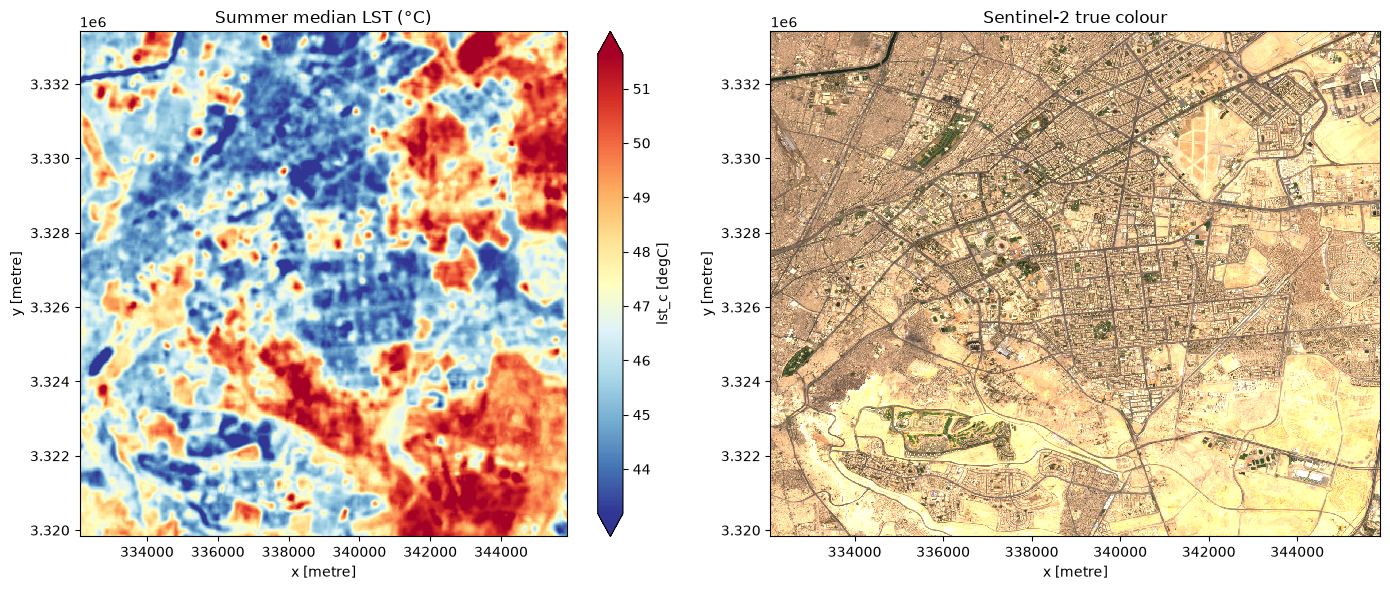

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
lst.plot(ax=ax[0], cmap='RdYlBu_r', robust=True)
ax[0].set_title('Summer median LST (°C)')
(s2[['B04','B03','B02']].to_array().transpose('y','x','variable') * 3.5).clip(0, 1).plot.imshow(ax=ax[1])
ax[1].set_title('Sentinel-2 true colour')
plt.tight_layout()

## Building heights
OSM tags where present, then Google Open Buildings 2.5D Temporal 2023 (median inside each footprint, CC BY 4.0 / ODbL), then a default. Open Buildings estimates are validated against the OSM-tagged heights.

In [5]:
from coolcairo.pipeline import load_osm_buildings, load_open_buildings_heights
from coolcairo import openbuildings
osm = load_osm_buildings(cfg)
ob = openbuildings.footprint_heights(osm, load_open_buildings_heights(cfg), cfg['open_buildings_min_pixels'])
print('Open Buildings vs OSM tags:', {k: round(v, 2) for k, v in openbuildings.validate_against_osm(osm, ob).items()})
buildings.height_source.value_counts(normalize=True).round(3)

Open Buildings vs OSM tags: {'n': 165, 'bias_m': -1.43, 'mae_m': 6.16, 'median_abs_err_m': 4.17, 'correlation': 0.6}


height_source
open_buildings    0.738
default           0.250
osm_levels        0.007
osm_height        0.004
Name: proportion, dtype: float64